# Selected 6 Planets — Interactive Transit Selection & Extraction

**Workflow per planet:**
1. Automatically picks the sector with the most transits (longest span relative to period)
2. Shows the full sector lightcurve — you **drag** to select each transit region (include ~1T baseline on each side)
3. Within each selection, finds the empirical midpoint (flux-weighted centroid)
4. Precisely extracts a gap-free **3T window** centred on that midpoint
5. Plots all extracted windows

> **Requires:** `ipympl` — if not installed run: `pip install ipympl` then restart the kernel.

In [3]:
# Run this cell once, then RESTART THE KERNEL before running anything else.
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ipympl', '-q'])
print('ipympl installed. Now restart the kernel (Kernel → Restart), then run cells in order.')


ipympl installed. Now restart the kernel (Kernel → Restart), then run cells in order.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector
from scipy.ndimage import uniform_filter1d
import lightkurve as lk
from pathlib import Path
import warnings, math

warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('../data/selected_transits')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_GAP_MIN      = 5.0    # gaps wider than this split a continuous run
MAX_FILL_GAP_MIN = 60.0   # only fill gaps narrower than this
CADENCE_MIN      = 2.0    # TESS 2-min cadence

R_sun = 6.957e8; R_jup = 7.149e7; AU = 1.496e11

PLANETS = {
    'WASP-078': dict(kind='UHJ', color='#c0392b', P=2.175, depth=0.811, Rp=2.060, Rs=2.350, a=0.03670),
    'WASP-072': dict(kind='UHJ', color='#c0392b', P=2.217, depth=0.434, Rp=1.270, Rs=1.980, a=0.03708),
    'TOI-4773': dict(kind='UHJ', color='#c0392b', P=1.745, depth=0.811, Rp=1.358, Rs=1.550, a=0.03216),
    'TrEs-5':   dict(kind='HJ',  color='#1a6b3c', P=1.482, depth=1.998, Rp=1.194, Rs=0.868, a=0.02446),
    'CoRoT-01': dict(kind='HJ',  color='#1a6b3c', P=1.509, depth=1.986, Rp=1.551, Rs=1.131, a=0.02536),
    'HATS-13':  dict(kind='HJ',  color='#1a6b3c', P=3.044, depth=1.972, Rp=1.212, Rs=0.887, a=0.04057),
}

def estimate_T14(P_days, Rs, Rp, a_AU):
    return (P_days / np.pi) * np.arcsin(np.clip((Rs*R_sun + Rp*R_jup) / (a_AU*AU), 0, 1))

def clean_lc(lc, sigma=3.0):
    lc   = lc.remove_nans().remove_outliers(sigma=sigma)
    time = np.asarray(lc.time.value, dtype=float)
    flux = np.asarray(lc.flux.value, dtype=float)
    flux = flux / np.nanmedian(flux)
    return time, flux

def window_has_gap(time, t_lo, t_hi, max_gap_min=5.0):
    mask = (time >= t_lo) & (time <= t_hi)
    t_w  = time[mask]
    if len(t_w) < 2: return True
    return bool(np.any(np.diff(t_w) > max_gap_min / 1440.0))

def fill_gaps_nn(time, flux, t_lo, t_hi,
                 cadence_min=2.0, max_fill_gap_min=60.0):
    cadence_d  = cadence_min / 1440.0
    max_fill_d = max_fill_gap_min / 1440.0

    mask  = (time >= t_lo) & (time <= t_hi)
    t_obs = time[mask]; f_obs = flux[mask]

    if len(t_obs) < 2:
        return t_obs, f_obs, np.zeros(len(t_obs), dtype=bool), []

    t_out     = np.arange(t_obs[0], t_obs[-1] + cadence_d * 0.5, cadence_d)
    f_out     = np.full(len(t_out), np.nan)
    is_filled = np.ones(len(t_out), dtype=bool)

    for i, tg in enumerate(t_out):
        idx = int(np.argmin(np.abs(t_obs - tg)))
        dt  = abs(t_obs[idx] - tg)
        if dt <= cadence_d * 0.6:
            f_out[i] = f_obs[idx]; is_filled[i] = False
        else:
            before = t_obs[t_obs < tg]; after = t_obs[t_obs > tg]
            if len(before) > 0 and len(after) > 0:
                if after[0] - before[-1] <= max_fill_d:
                    f_out[i] = f_obs[idx]

    gap_info = []
    for gi in np.where(np.diff(t_obs) > cadence_d * 1.5)[0]:
        gap_info.append((t_obs[gi], t_obs[gi+1], (t_obs[gi+1]-t_obs[gi])*1440.0))

    valid = ~np.isnan(f_out)
    return t_out[valid], f_out[valid], is_filled[valid], gap_info


def find_empirical_midpoint(t, f, t_lo, t_hi, T14_d):
    """
    Three-step approach:
      1. Sliding T14-window scan → robust coarse midpoint (works at SNR~1)
      2. Parabolic fit around the scan winner → sub-cadence precision
      3. T14-informed flux-weighted centroid → physical refinement
    Returns (t_mid, depth, snr, method_str)
    """
    mask = (t >= t_lo) & (t <= t_hi)
    t_w  = t[mask]; f_w = f[mask]
    if len(t_w) < 5:
        return None, 0.0, 0.0, 'TOO_FEW'

    half = T14_d / 2.0

    # Step 1: sliding scan (500 candidates)
    candidates = np.linspace(t_lo + half, t_hi - half, 500)
    scores     = np.full(len(candidates), np.nan)
    for ci, tc in enumerate(candidates):
        in_m = (t_w >= tc - half) & (t_w <= tc + half)
        if in_m.sum() >= 3:
            scores[ci] = np.median(f_w[in_m])
    valid_c = ~np.isnan(scores)
    if not valid_c.any():
        return None, 0.0, 0.0, 'SCAN_FAILED'
    t_scan = float(candidates[valid_c][np.argmin(scores[valid_c])])

    # Step 2: parabolic refinement around scan winner
    refine_hw = T14_d
    r_mask    = (t_w >= t_scan - refine_hw) & (t_w <= t_scan + refine_hw)
    t_r = t_w[r_mask]; f_r = f_w[r_mask]
    t_parab    = t_scan; parab_conf = 0.0
    if len(t_r) >= 5:
        smooth  = uniform_filter1d(f_r, size=max(3, len(t_r) // 6))
        idx_min = int(np.argmin(smooth))
        hw2 = max(4, len(t_r) // 5)
        lo2 = max(0, idx_min - hw2); hi2 = min(len(t_r), idx_min + hw2 + 1)
        try:
            c = np.polyfit(t_r[lo2:hi2], f_r[lo2:hi2], 2)
            if c[0] > 0:
                t_v = -c[1] / (2 * c[0])
                if t_r.min() <= t_v <= t_r.max():
                    t_parab = float(t_v); parab_conf = float(c[0])
        except Exception:
            pass

    # Step 3: T14 centroid around parabolic peak
    in_mask  = (t_w >= t_parab - half) & (t_w <= t_parab + half)
    out_mask = ~in_mask
    t_centroid = None; snr = 0.0; depth = 0.0
    if in_mask.sum() >= 3 and out_mask.sum() >= 3:
        baseline = float(np.nanmedian(f_w[out_mask]))
        noise    = float(np.nanstd(f_w[out_mask]))
        depth    = baseline - float(np.nanmedian(f_w[in_mask]))
        snr      = depth / noise if noise > 0 else 0.0
        weights  = np.clip(baseline - f_w[in_mask], 0, None)
        if weights.sum() > 0 and snr >= 1.0:
            t_centroid = float(np.sum(weights * t_w[in_mask]) / weights.sum())

    # Blend
    if t_centroid is not None and snr >= 2.0:
        w_p = min(parab_conf * 1e6, 5.0); w_c = snr
        t_mid  = (w_p * t_parab + w_c * t_centroid) / (w_p + w_c)
        method = f'SCAN+BLEND(SNR={snr:.1f})'
    elif t_centroid is not None and snr >= 1.0:
        t_mid  = 0.75 * t_parab + 0.25 * t_centroid
        method = f'SCAN+PAR+nudge(SNR={snr:.1f})'
    else:
        t_mid  = t_parab
        method = 'SCAN+PARAB'

    return float(t_mid), float(depth), float(snr), method


SELECTED_REGIONS = []
print('Setup complete. Run next cell to download data.')


Setup complete. Run next cell to download data.


c:\Users\pnayg\Desktop\cvif-astro-p1\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
PLANET_DATA = {}

for planet, cfg in PLANETS.items():
    P     = cfg['P']
    T14_d = estimate_T14(P, cfg['Rs'], cfg['Rp'], cfg['a'])
    print(f'[{planet}] Downloading...', flush=True)
    try:
        sr = lk.search_lightcurve(planet, mission='TESS', cadence=120, author='SPOC')
        if len(sr) == 0:
            print('  No data.'); continue
        lc_collection = sr.download_all(quality_bitmask='default')
    except Exception as e:
        print(f'  Error: {e}'); continue

    # Find sector with most transits (longest span / P)
    best_sector = None; best_n = 0; best_time = None; best_flux = None
    all_sectors = []
    for lc_raw in lc_collection:
        sec = lc_raw.meta.get('SECTOR', '?')
        try:
            t, f = clean_lc(lc_raw)
        except:
            continue
        n = (t[-1] - t[0]) / P
        all_sectors.append((sec, t, f, n))
        if n > best_n:
            best_n = n; best_sector = sec; best_time = t; best_flux = f

    if best_time is None:
        print('  No usable data.'); continue

    PLANET_DATA[planet] = dict(
        cfg=cfg, T14_d=T14_d, sector=best_sector,
        time=best_time, flux=best_flux, n_transits=best_n
    )
    print(f'  Best sector: {best_sector} | ~{best_n:.1f} transits | span={best_time[-1]-best_time[0]:.1f} d')

print('\nDone. Run next cell to open interactive selector.')


[WASP-078] Downloading...
  Best sector: 32 | ~11.9 transits | span=25.8 d
[WASP-072] Downloading...


  Best sector: 97 | ~23.5 transits | span=52.1 d
[TOI-4773] Downloading...
  Best sector: 88 | ~15.9 transits | span=27.8 d
[TrEs-5] Downloading...
  Best sector: 57 | ~19.4 transits | span=28.8 d
[CoRoT-01] Downloading...
  Best sector: 33 | ~17.1 transits | span=25.8 d
[HATS-13] Downloading...
  Best sector: 1 | ~9.1 transits | span=27.7 d

Done. Run next cell to open interactive selector.


In [16]:
# ── CHANGE THIS to pick which planet to select transits for ──────────────────
PLANET_NAME = 'CoRoT-01'   # one of the keys in PLANETS
WINDOW_PERIODS = 4         # how many orbital periods to show per view
# ─────────────────────────────────────────────────────────────────────────────

# Controls:
#   Drag        = highlight a transit region (yellow)
#   A           = confirm → turns green, computes empirical midpoint
#   R           = remove last confirmed selection
#   ← / →       = Previous / Next page  (or use the buttons)
#   Q           = quit

%matplotlib tk

data       = PLANET_DATA[PLANET_NAME]
cfg        = data['cfg']
time       = data['time']
flux       = data['flux']
T14_d      = data['T14_d']
color      = cfg['color']
depth      = cfg['depth']
depth_frac = depth / 100.0
P          = cfg['P']

window_width = WINDOW_PERIODS * P          # days shown per view
step         = window_width * 0.6          # overlap so no transit falls on edge

view = {'t_start': time[0]}

current_sel   = {'t_lo': None, 't_hi': None}
session_regs  = []
saved_patches = []   # per-view patches (rebuilt on each pan)
saved_lines   = []

# ── Y limits (fixed for entire sector so axis doesn't jump while panning) ────
fp1  = np.nanpercentile(flux, 1)
fp99 = np.nanpercentile(flux, 99)
mg   = max(3*depth_frac, (fp99-fp1)*0.1, 0.002)
y_lo = min(fp1,  1.0 - 2*depth_frac) - mg*0.5
y_hi = max(fp99, 1.0 + depth_frac)   + mg*0.5

# ── Figure layout ─────────────────────────────────────────────────────────────
from matplotlib.widgets import Button as MplButton

fig = plt.figure(figsize=(15, 6))
ax  = fig.add_axes([0.06, 0.18, 0.91, 0.72])   # main plot

ax_prev = fig.add_axes([0.06,  0.03, 0.08, 0.07])
ax_next = fig.add_axes([0.15,  0.03, 0.08, 0.07])
btn_prev = MplButton(ax_prev, '◀ Prev')
btn_next = MplButton(ax_next, 'Next ▶')

status = fig.text(0.30, 0.055, 'Drag to select a transit   |   A=confirm   R=remove   Q=quit',
                  fontsize=9, va='center',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85))

def render_view():
    """Redraw the current window slice."""
    t0 = view['t_start']
    t1 = t0 + window_width
    mask = (time >= t0) & (time <= t1)

    ax.cla()
    ax.plot(time[mask], flux[mask], '.', ms=2.0, color=color, alpha=0.75, zorder=2)
    ax.set_xlim(t0, t1)
    ax.set_ylim(y_lo, y_hi)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
    ax.set_xlabel('BTJD', fontsize=10)
    ax.set_ylabel('Norm. Flux', fontsize=10)

    pct = (t0 - time[0]) / max(time[-1] - time[0], 1e-9) * 100
    ax.set_title(
        f'{PLANET_NAME} ({cfg["kind"]})  ·  Sector {data["sector"]}  ·  '
        f'P={P:.3f} d  ·  T14={T14_d*24:.2f} h  ·  depth={depth:.3f}%  ·  '
        f'[{t0:.2f} – {t1:.2f}]  ({pct:.0f}% through sector)',
        fontsize=9
    )

    # Redraw all confirmed selections that overlap this window
    for r in session_regs:
        if r['t_hi'] >= t0 and r['t_lo'] <= t1:
            ax.axvspan(r['t_lo'], r['t_hi'], alpha=0.22, color='limegreen', zorder=1)
            ax.axvline(r['t_mid'], color='darkgreen', lw=1.2, ls='--', alpha=0.9, zorder=3)

    # Redraw current (unconfirmed) yellow highlight if in range
    if current_sel['t_lo'] is not None:
        t_lo = current_sel['t_lo']; t_hi = current_sel['t_hi']
        if t_hi >= t0 and t_lo <= t1:
            ax.axvspan(t_lo, t_hi, alpha=0.35, color='gold', zorder=1)

    fig.canvas.draw_idle()

    # Re-attach SpanSelector to fresh axes
    attach_span()

span_holder = [None]

def attach_span():
    span_holder[0] = SpanSelector(
        ax, onselect, 'horizontal',
        useblit=True,
        props=dict(alpha=0.35, facecolor='gold'),
        interactive=True,
        drag_from_anywhere=True
    )

def onselect(t_lo, t_hi):
    current_sel['t_lo'] = t_lo
    current_sel['t_hi'] = t_hi
    dur_h = (t_hi - t_lo) * 24
    n_pts = int(((time >= t_lo) & (time <= t_hi)).sum())
    status.set_text(
        f'Selected: {t_lo:.4f} – {t_hi:.4f} BTJD  ({dur_h:.2f} h, {n_pts} pts)  |  '
        f'Press  A  to confirm'
    )
    fig.canvas.draw_idle()

def on_key(event):
    if event.key == 'a':
        t_lo = current_sel['t_lo']; t_hi = current_sel['t_hi']
        if t_lo is None:
            status.set_text('Nothing selected — drag first.'); fig.canvas.draw_idle(); return

        t_mid, dep, snr, method = find_empirical_midpoint(time, flux, t_lo, t_hi, T14_d)
        if t_mid is None:
            status.set_text('Too few points — try a wider drag.'); fig.canvas.draw_idle(); return

        reg = dict(planet=PLANET_NAME, sector=data['sector'],
                   t_lo=t_lo, t_hi=t_hi, t_mid=t_mid,
                   depth=dep, snr=snr, method=method)
        session_regs.append(reg)
        SELECTED_REGIONS.append(reg)
        current_sel['t_lo'] = None
        render_view()
        status.set_text(
            f'#{len(session_regs)} confirmed  ·  {method}  ·  '
            f't_mid={t_mid:.6f}  ·  depth={dep:.5f}  ·  SNR={snr:.1f}  |  '
            f'Drag next or press  Q'
        )
        print(f'  #{len(session_regs)}: t_mid={t_mid:.6f} | SNR={snr:.1f} | {method}')

    elif event.key == 'r':
        if session_regs:
            rem = session_regs.pop(); SELECTED_REGIONS.remove(rem)
            render_view()
            status.set_text(f'Removed last. {len(session_regs)} remaining.')
            print(f'  Removed: t_mid={rem["t_mid"]:.6f}')
        else:
            status.set_text('Nothing to remove.'); fig.canvas.draw_idle()

    elif event.key in ('right', 'd'):
        view['t_start'] = min(view['t_start'] + step, time[-1] - window_width)
        current_sel['t_lo'] = None
        render_view()
        status.set_text('Drag to select a transit   |   A=confirm   R=remove   Q=quit')

    elif event.key in ('left', 'a') and event.key != 'a':
        view['t_start'] = max(view['t_start'] - step, time[0])
        current_sel['t_lo'] = None
        render_view()
        status.set_text('Drag to select a transit   |   A=confirm   R=remove   Q=quit')

    elif event.key == 'q':
        plt.close(fig)
        print(f'\nDone. {len(session_regs)} transit(s) saved for {PLANET_NAME}.')
        print(f'Total across all planets: {len(SELECTED_REGIONS)}')

def on_prev(event):
    view['t_start'] = max(view['t_start'] - step, time[0])
    current_sel['t_lo'] = None
    render_view()

def on_next(event):
    view['t_start'] = min(view['t_start'] + step, time[-1] - window_width)
    current_sel['t_lo'] = None
    render_view()

fig.canvas.mpl_connect('key_press_event', on_key)
btn_prev.on_clicked(on_prev)
btn_next.on_clicked(on_next)

render_view()
plt.show()

print(f'\nPopup opened for {PLANET_NAME}  (window = {WINDOW_PERIODS} periods = {window_width:.2f} d).')
print('Controls:  Drag=select   A=confirm   R=remove last   ←/→ or buttons=page   Q=quit')



Popup opened for CoRoT-01  (window = 4 periods = 6.04 d).
Controls:  Drag=select   A=confirm   R=remove last   ←/→ or buttons=page   Q=quit


  #1: t_mid=2202.420263 | SNR=2.2 | SCAN+BLEND(SNR=2.2)
  #2: t_mid=2203.937155 | SNR=2.1 | SCAN+BLEND(SNR=2.1)
  #3: t_mid=2205.443995 | SNR=2.1 | SCAN+BLEND(SNR=2.1)
  #4: t_mid=2206.950107 | SNR=2.1 | SCAN+BLEND(SNR=2.1)
  #5: t_mid=2209.968027 | SNR=1.7 | SCAN+PAR+nudge(SNR=1.7)
  #6: t_mid=2211.483392 | SNR=1.8 | SCAN+PAR+nudge(SNR=1.8)
  #7: t_mid=2212.991749 | SNR=1.8 | SCAN+PAR+nudge(SNR=1.8)
  #8: t_mid=2216.004773 | SNR=1.7 | SCAN+PAR+nudge(SNR=1.7)
  #9: t_mid=2217.512792 | SNR=2.0 | SCAN+PAR+nudge(SNR=2.0)
  #10: t_mid=2219.028774 | SNR=2.3 | SCAN+BLEND(SNR=2.3)
  #11: t_mid=2220.532387 | SNR=1.6 | SCAN+PAR+nudge(SNR=1.6)
  #12: t_mid=2222.046629 | SNR=1.9 | SCAN+PAR+nudge(SNR=1.9)
  #13: t_mid=2223.551594 | SNR=2.1 | SCAN+BLEND(SNR=2.1)
  #14: t_mid=2225.060756 | SNR=1.8 | SCAN+PAR+nudge(SNR=1.8)
  #15: t_mid=2226.572234 | SNR=1.7 | SCAN+PAR+nudge(SNR=1.7)

Done. 15 transit(s) saved for CoRoT-01.
Total across all planets: 50



TOI-4773 — 15 selection(s)
  #1: t_mid=3691.036273 | 296 pts [14 pts NN-filled]
  #2: t_mid=3692.785960 | 297 pts [13 pts NN-filled]
  #3: t_mid=3694.530343 | 297 pts [18 pts NN-filled]
  #4: t_mid=3696.272191 | 296 pts [14 pts NN-filled]
  #5: t_mid=3699.765058 | 297 pts [12 pts NN-filled]
  #6: t_mid=3701.512788 | 296 pts [21 pts NN-filled]
  #7: t_mid=3703.255586 | 296 pts [13 pts NN-filled]
  #8: t_mid=3705.003251 | 296 pts [10 pts NN-filled]
  #9: t_mid=3706.747034 | 297 pts [17 pts NN-filled]
  #10: t_mid=3708.492047 | 296 pts [9 pts NN-filled]
  #11: t_mid=3710.237473 | 296 pts [13 pts NN-filled]
  #12: t_mid=3711.982659 | 296 pts [11 pts NN-filled]
  #13: t_mid=3713.730833 | 296 pts [15 pts NN-filled]
  #14: t_mid=3715.474398 | 296 pts [10 pts NN-filled]
  #15: t_mid=3717.221926 | 296 pts [45 pts NN-filled]
  15 valid 3T window(s) extracted.


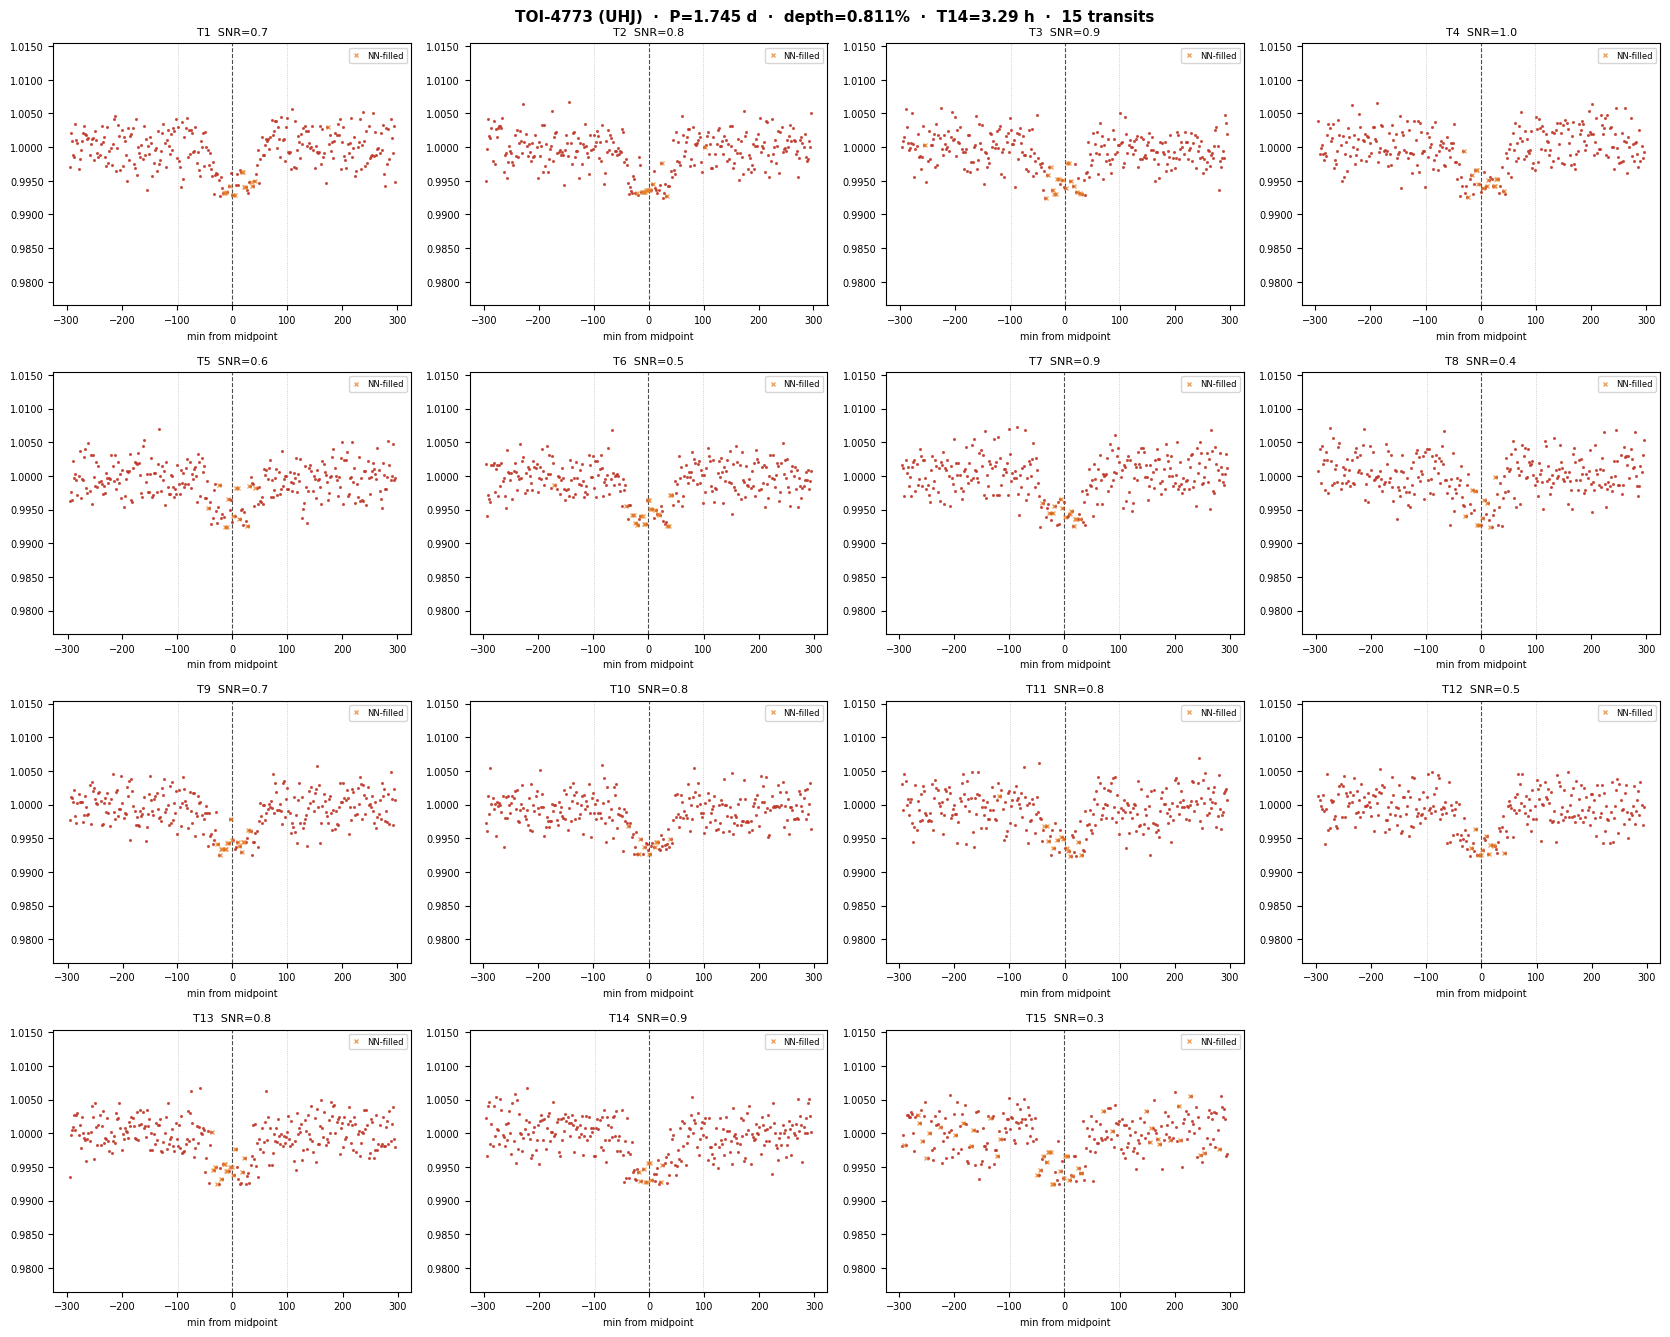


TrEs-5 — 6 selection(s)
  #1: t_mid=2854.419018 | 193 pts [30 pts NN-filled]
  #2: t_mid=2855.900388 | 193 pts [30 pts NN-filled]
  #3: t_mid=2857.381315 | 193 pts [26 pts NN-filled]
  #4: t_mid=2858.864176 | 193 pts [34 pts NN-filled]
  #5: t_mid=2860.349295 | 193 pts [34 pts NN-filled]
  #6: t_mid=2861.828743 | 193 pts [30 pts NN-filled]
  6 valid 3T window(s) extracted.


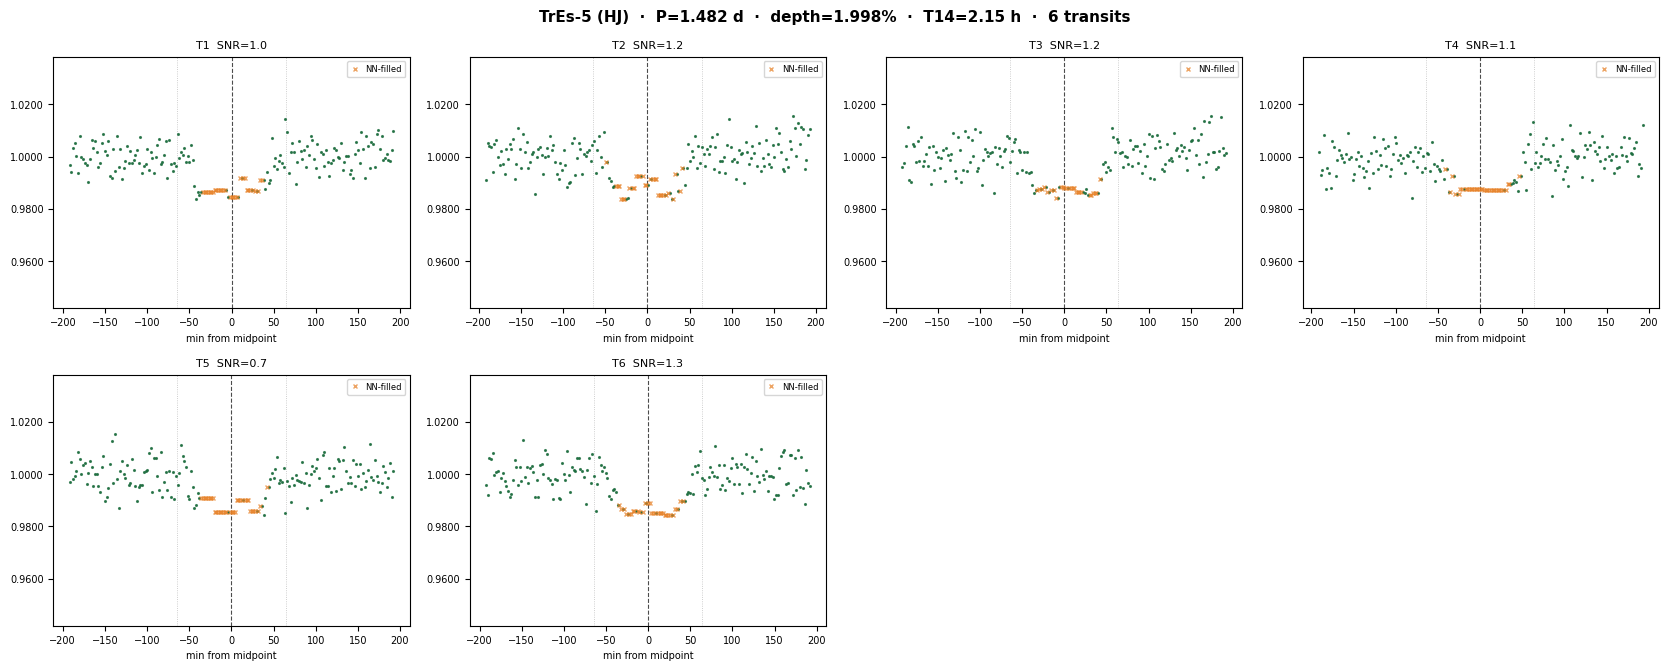


WASP-072 — 14 selection(s)
  #1: t_mid=3937.086390 | 409 pts [28 pts NN-filled]
  #2: t_mid=3939.304091 | 408 pts [34 pts NN-filled]
  #3: t_mid=3941.518635 | 409 pts [41 pts NN-filled]
  #4: t_mid=3943.717051 | 408 pts [39 pts NN-filled]
  #5: t_mid=3945.949820 | 408 pts [41 pts NN-filled]
  #6: t_mid=3950.382719 | 409 pts [32 pts NN-filled]
  #7: t_mid=3952.604132 | 408 pts [44 pts NN-filled]
  #8: t_mid=3954.816636 | 408 pts [37 pts NN-filled]
  #9: t_mid=3957.034934 | 408 pts [50 pts NN-filled]
  #10: t_mid=3959.249481 | 409 pts [52 pts NN-filled]
  #11: t_mid=3965.904855 | 408 pts [33 pts NN-filled]
  #12: t_mid=3968.120956 | 408 pts [29 pts NN-filled]
  #13: t_mid=3970.337720 | 408 pts [48 pts NN-filled]
  #14: t_mid=3972.551788 | 408 pts [47 pts NN-filled]
  14 valid 3T window(s) extracted.


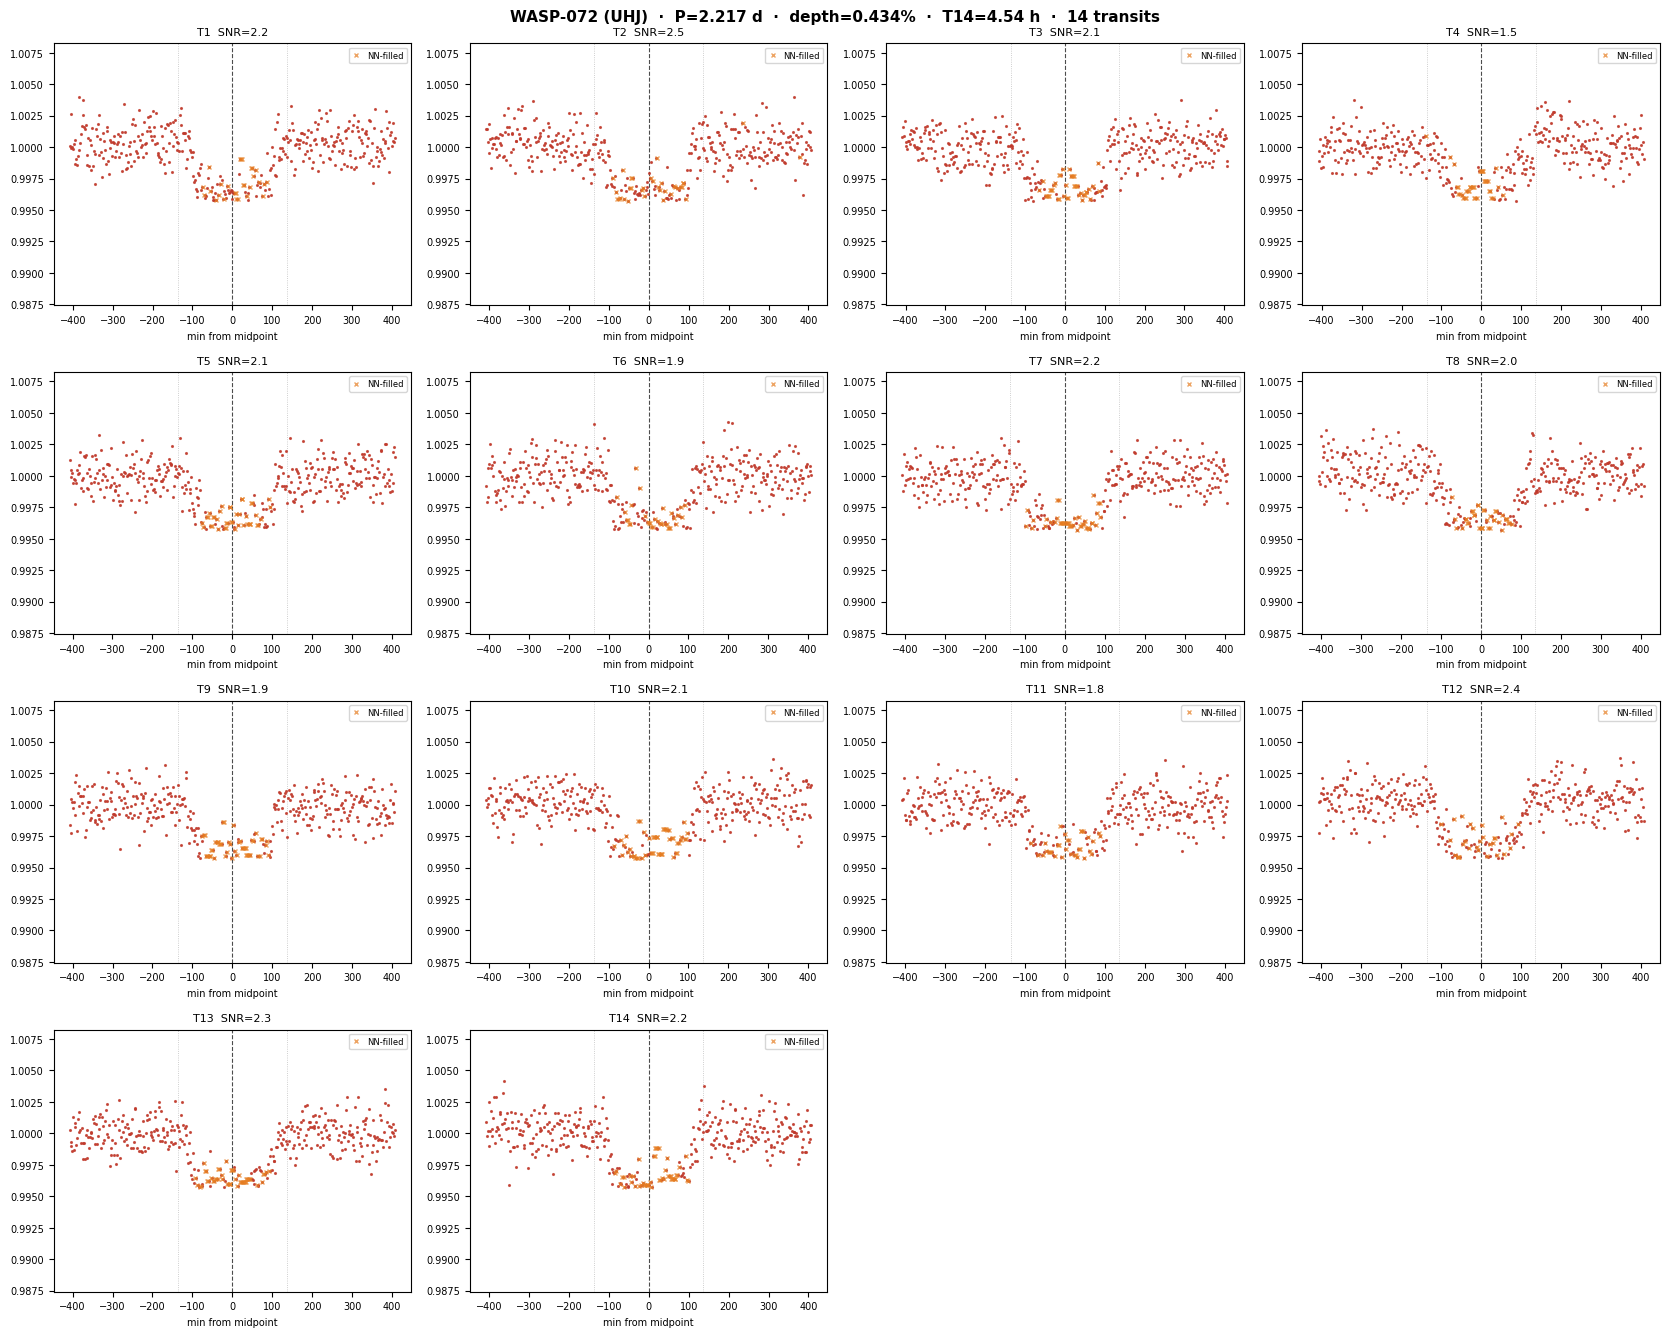


CoRoT-01 — 15 selection(s)
  #1: t_mid=2202.420263 | 248 pts [13 pts NN-filled]
  #2: t_mid=2203.937155 | 248 pts [11 pts NN-filled]
  #3: t_mid=2205.443995 | 248 pts [22 pts NN-filled]
  #4: t_mid=2206.950107 | 248 pts [15 pts NN-filled]
  #5: t_mid=2209.968027 | 248 pts [9 pts NN-filled]
  #6: t_mid=2211.483392 | 248 pts [8 pts NN-filled]
  #7: t_mid=2212.991749 | 248 pts [17 pts NN-filled]
  #8: t_mid=2216.004773 | 248 pts [17 pts NN-filled]
  #9: t_mid=2217.512792 | 248 pts [14 pts NN-filled]
  #10: t_mid=2219.028774 | 248 pts [10 pts NN-filled]
  #11: t_mid=2220.532387 | 247 pts [23 pts NN-filled]
  #12: t_mid=2222.046629 | 248 pts [15 pts NN-filled]
  #13: t_mid=2223.551594 | 248 pts [9 pts NN-filled]
  #14: t_mid=2225.060756 | 248 pts [12 pts NN-filled]
  #15: t_mid=2226.572234 | 248 pts [25 pts NN-filled]
  15 valid 3T window(s) extracted.


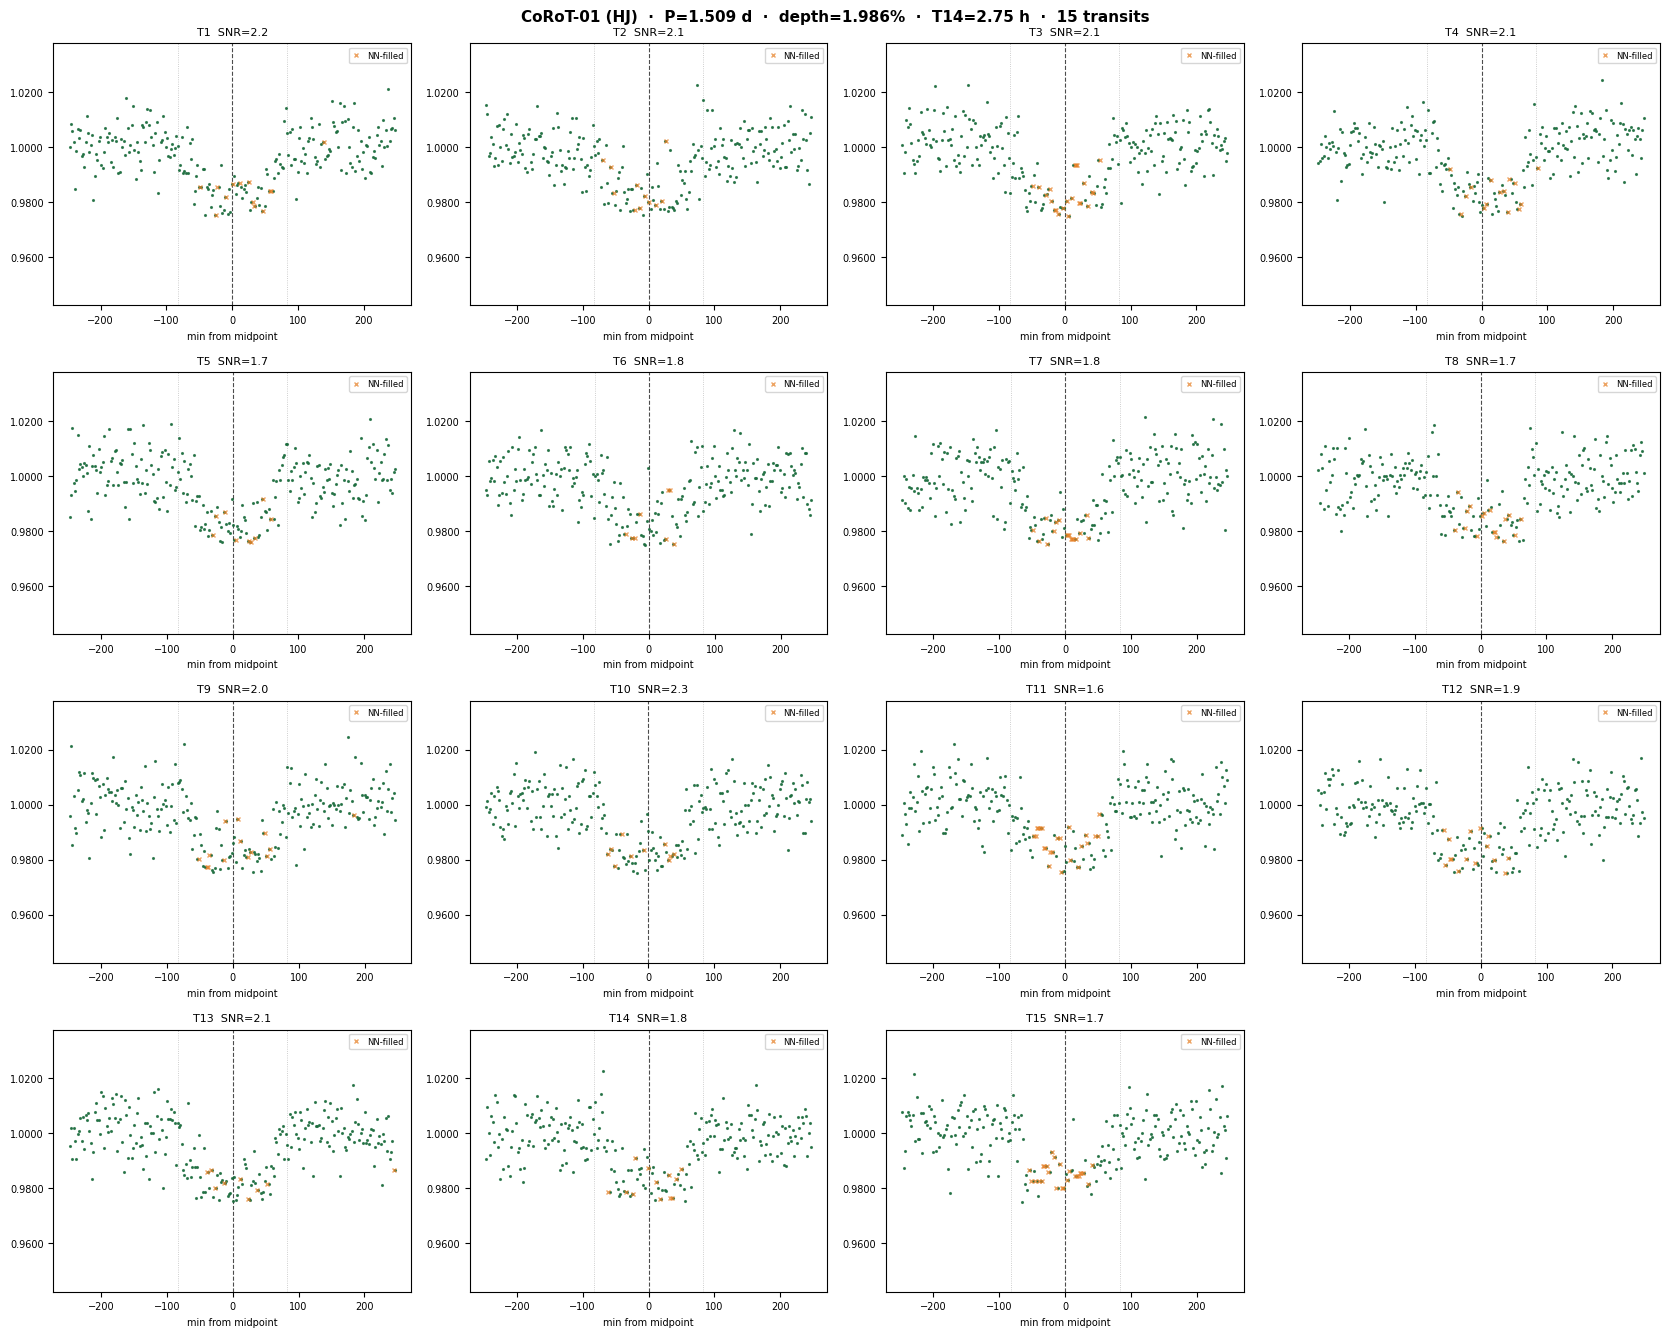


── Summary ──
  TOI-4773: 15 transit(s)  [235 NN-filled points total]
  TrEs-5: 6 transit(s)  [184 NN-filled points total]
  WASP-072: 14 transit(s)  [555 NN-filled points total]
  CoRoT-01: 15 transit(s)  [220 NN-filled points total]
  TOTAL: 50 transit windows


In [18]:
# ── Extract 3T windows from all confirmed selections and plot them ────────────
# Gaps narrower than MAX_FILL_GAP_MIN are filled by nearest-neighbour interpolation.

%matplotlib inline

RESULTS = {}

planets_done = list({r['planet'] for r in SELECTED_REGIONS})

for planet in planets_done:
    regs       = [r for r in SELECTED_REGIONS if r['planet'] == planet]
    data       = PLANET_DATA[planet]
    cfg        = data['cfg']
    time       = data['time']
    flux       = data['flux']
    T14_d      = data['T14_d']
    color      = cfg['color']
    depth      = cfg['depth']
    depth_frac = depth / 100.0
    half_T14_min = (T14_d / 2) * 1440

    print(f'\n{planet} — {len(regs)} selection(s)')
    windows = []; skipped = []

    for i, r in enumerate(regs):
        t_lo = r['t_mid'] - 1.5 * T14_d
        t_hi = r['t_mid'] + 1.5 * T14_d

        if t_lo < time[0] or t_hi > time[-1]:
            skipped.append(f'#{i+1}: out of bounds'); continue

        t_w, f_w, is_filled, gap_info = fill_gaps_nn(
            time, flux, t_lo, t_hi,
            cadence_min=CADENCE_MIN,
            max_fill_gap_min=MAX_FILL_GAP_MIN
        )

        if len(t_w) < 5:
            skipped.append(f'#{i+1}: too few points after fill'); continue

        coverage = len(t_w) / max(1, (t_hi - t_lo) / (CADENCE_MIN / 1440.0))
        if coverage < 0.5:
            skipped.append(f'#{i+1}: <50% coverage even after fill'); continue

        n_filled  = int(is_filled.sum())
        fill_note = f' [{n_filled} pts NN-filled]' if n_filled > 0 else ''

        windows.append(dict(
            num=i+1, t_mid=r['t_mid'], depth=r['depth'],
            snr=r['snr'], method=r.get('method', ''),
            time=t_w, flux=f_w, is_filled=is_filled,
            gap_info=gap_info, fill_note=fill_note
        ))
        print(f'  #{i+1}: t_mid={r["t_mid"]:.6f} | {len(t_w)} pts{fill_note}')

    if skipped:
        print('  Skipped:', ', '.join(skipped))
    print(f'  {len(windows)} valid 3T window(s) extracted.')
    RESULTS[planet] = windows

    if not windows: continue

    NCOLS = 4
    nrows = math.ceil(len(windows) / NCOLS)
    fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS*4.2, nrows*3.4), squeeze=False)
    fig.suptitle(
        f'{planet} ({cfg["kind"]})  ·  P={cfg["P"]:.3f} d  ·  '
        f'depth={depth:.3f}%  ·  T14={T14_d*24:.2f} h  ·  {len(windows)} transits',
        fontsize=11, fontweight='bold'
    )
    for idx, w in enumerate(windows):
        ax  = axes[idx//NCOLS][idx%NCOLS]
        x   = (w['time'] - w['t_mid']) * 1440.0
        fld = w['is_filled']

        ax.plot(x[~fld], w['flux'][~fld], '.', ms=2.5, color=color, alpha=0.8, zorder=3)
        if fld.any():
            ax.plot(x[fld], w['flux'][fld], 'x', ms=3.5, color='#e67e22',
                    alpha=0.7, zorder=4, label='NN-filled')
            ax.legend(fontsize=6, loc='upper right', handlelength=1)

        ax.axvline(0,             color='black', lw=0.8, ls='--', alpha=0.7)
        ax.axvline(-half_T14_min, color='gray',  lw=0.6, ls=':',  alpha=0.5)
        ax.axvline( half_T14_min, color='gray',  lw=0.6, ls=':',  alpha=0.5)
        fp1  = np.nanpercentile(w['flux'], 1)
        fp99 = np.nanpercentile(w['flux'], 99)
        mg   = max(3*depth_frac, (fp99-fp1)*0.1, 0.002)
        ax.set_ylim(min(fp1, 1.0-2*depth_frac)-mg*0.3, max(fp99, 1.0+depth_frac)+mg*0.3)
        ax.set_title(f'T{w["num"]}  SNR={w["snr"]:.1f}', fontsize=8)
        ax.set_xlabel('min from midpoint', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
    for idx in range(len(windows), nrows*NCOLS):
        axes[idx//NCOLS][idx%NCOLS].set_visible(False)
    plt.tight_layout(); plt.show()

print('\n── Summary ──')
total = 0
for planet, wins in RESULTS.items():
    total_filled = sum(int(w['is_filled'].sum()) for w in wins)
    print(f'  {planet}: {len(wins)} transit(s)  [{total_filled} NN-filled points total]')
    total += len(wins)
print(f'  TOTAL: {total} transit windows')


In [14]:
# ── Save each transit: individual PNG + CSV ───────────────────────────────────
# Folder structure:
#   data/selected_transits/
#     WASP-078/
#       WASP-078_T01_sector42_tmid1234.5678.csv   ← has 'interpolated' column
#       WASP-078_T01_sector42_tmid1234.5678.png
#     transit_index.csv

%matplotlib inline

saved_files = []

for planet, windows in RESULTS.items():
    if not windows:
        continue

    planet_dir = OUTPUT_DIR / planet.replace(' ', '_')
    planet_dir.mkdir(parents=True, exist_ok=True)

    cfg          = PLANETS[planet]
    T14_d        = PLANET_DATA[planet]['T14_d']
    color        = cfg['color']
    depth        = cfg['depth']
    depth_frac   = depth / 100.0
    sector       = PLANET_DATA[planet]['sector']
    half_T14_min = (T14_d / 2) * 1440

    for w in windows:
        stem = (
            f"{planet.replace(' ','_')}_"
            f"T{w['num']:02d}_"
            f"sector{sector:02d}_"
            f"tmid{w['t_mid']:.4f}"
        )
        csv_path = planet_dir / f"{stem}.csv"
        png_path = planet_dir / f"{stem}.png"

        # ── CSV ──────────────────────────────────────────────────────────────
        t_rel_min  = (w['time'] - w['t_mid']) * 1440.0
        is_filled  = w['is_filled']
        n_filled   = int(is_filled.sum())
        n_real     = int((~is_filled).sum())

        df = pd.DataFrame({
            'time_btjd':         w['time'],
            'time_min_from_mid': t_rel_min,
            'flux':              w['flux'],
            'interpolated':      is_filled.astype(int),  # 0=observed, 1=NN-filled
        })
        header = (
            f"# planet:           {planet}\n"
            f"# kind:             {cfg['kind']}\n"
            f"# sector:           {sector}\n"
            f"# transit_num:      {w['num']}\n"
            f"# t_mid_btjd:       {w['t_mid']:.8f}\n"
            f"# T14_days:         {T14_d:.6f}\n"
            f"# T14_hours:        {T14_d*24:.4f}\n"
            f"# depth_frac:       {w['depth']:.6f}\n"
            f"# snr:              {w['snr']:.2f}\n"
            f"# method:           {w.get('method','')}\n"
            f"# n_points_total:   {len(w['time'])}\n"
            f"# n_points_real:    {n_real}\n"
            f"# n_points_filled:  {n_filled}\n"
            f"# interpolated:     1=NN-filled from nearest observed point, 0=observed\n"
            f"# window_lo_btjd:   {w['t_mid'] - 1.5*T14_d:.8f}\n"
            f"# window_hi_btjd:   {w['t_mid'] + 1.5*T14_d:.8f}\n"
        )
        with open(csv_path, 'w') as f:
            f.write(header)
            df.to_csv(f, index=False)

        # ── PNG ──────────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(8, 4.5))

        fld = w['is_filled']
        x   = (w['time'] - w['t_mid']) * 1440.0

        # Observed points
        ax.plot(x[~fld], w['flux'][~fld], '.', ms=3.0, color=color,
                alpha=0.85, zorder=3, label='Observed')
        # NN-filled points (orange ×)
        if fld.any():
            ax.plot(x[fld], w['flux'][fld], 'x', ms=4.0, color='#e67e22',
                    alpha=0.75, zorder=4, label=f'NN-filled ({n_filled} pts)')

        # Midpoint and contact lines
        ax.axvline(0,             color='black', lw=1.0, ls='--', alpha=0.8,
                   label='Empirical midpoint', zorder=5)
        ax.axvline(-half_T14_min, color='gray',  lw=0.8, ls=':',  alpha=0.6,
                   label=f'±T14/2 ({half_T14_min:.1f} min)')
        ax.axvline( half_T14_min, color='gray',  lw=0.8, ls=':',  alpha=0.6)

        # Shaded transit region
        ax.axvspan(-half_T14_min, half_T14_min, color=color, alpha=0.07, zorder=1)
        ax.axhline(1.0, color='silver', lw=0.6, ls='-', zorder=0)

        # Y limits
        fp1  = np.nanpercentile(w['flux'], 1)
        fp99 = np.nanpercentile(w['flux'], 99)
        mg   = max(3*depth_frac, (fp99-fp1)*0.1, 0.002)
        ax.set_ylim(min(fp1, 1.0-2*depth_frac) - mg*0.4,
                    max(fp99, 1.0+depth_frac)   + mg*0.4)

        ax.set_xlabel('Minutes from empirical midpoint', fontsize=11)
        ax.set_ylabel('Normalised Flux', fontsize=11)
        ax.set_title(
            f'{planet} ({cfg["kind"]})  ·  Transit {w["num"]}  ·  Sector {sector}\n'
            f't_mid = {w["t_mid"]:.6f} BTJD  ·  depth = {w["depth"]:.5f}  ·  '
            f'SNR = {w["snr"]:.1f}  ·  {n_real} obs + {n_filled} filled',
            fontsize=9
        )
        ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
        ax.tick_params(labelsize=9)
        ax.legend(fontsize=8, loc='lower center', ncol=2)

        plt.tight_layout()
        fig.savefig(png_path, dpi=150, bbox_inches='tight')
        plt.close(fig)

        saved_files.append(dict(
            planet=planet, kind=cfg['kind'], sector=sector,
            transit_num=w['num'], t_mid=w['t_mid'],
            snr=w['snr'], method=w.get('method',''),
            n_points=len(w['time']), n_filled=n_filled,
            csv=str(csv_path), png=str(png_path)
        ))
        print(f'  Saved: {stem}  ({n_real} obs + {n_filled} NN-filled)')

# ── Index CSV ─────────────────────────────────────────────────────────────────
index_df   = pd.DataFrame(saved_files)
index_path = OUTPUT_DIR / 'transit_index.csv'
index_df.to_csv(index_path, index=False)

print(f'\n{len(saved_files)} transit(s) saved to {OUTPUT_DIR}')
print(f'Index: {index_path}\n')
print(index_df[['planet','kind','sector','transit_num','t_mid','snr','method','n_points','n_filled']].to_string(index=False))


  Saved: TOI-4773_T01_sector88_tmid3691.0363  (282 obs + 14 NN-filled)
  Saved: TOI-4773_T02_sector88_tmid3692.7860  (284 obs + 13 NN-filled)
  Saved: TOI-4773_T03_sector88_tmid3694.5303  (279 obs + 18 NN-filled)
  Saved: TOI-4773_T04_sector88_tmid3696.2722  (282 obs + 14 NN-filled)
  Saved: TOI-4773_T05_sector88_tmid3699.7651  (285 obs + 12 NN-filled)
  Saved: TOI-4773_T06_sector88_tmid3701.5128  (275 obs + 21 NN-filled)
  Saved: TOI-4773_T07_sector88_tmid3703.2556  (283 obs + 13 NN-filled)
  Saved: TOI-4773_T08_sector88_tmid3705.0033  (286 obs + 10 NN-filled)
  Saved: TOI-4773_T09_sector88_tmid3706.7470  (280 obs + 17 NN-filled)
  Saved: TOI-4773_T10_sector88_tmid3708.4920  (287 obs + 9 NN-filled)
  Saved: TOI-4773_T11_sector88_tmid3710.2375  (283 obs + 13 NN-filled)
  Saved: TOI-4773_T12_sector88_tmid3711.9827  (285 obs + 11 NN-filled)
  Saved: TOI-4773_T13_sector88_tmid3713.7308  (281 obs + 15 NN-filled)
  Saved: TOI-4773_T14_sector88_tmid3715.4744  (286 obs + 10 NN-filled)
  Saved

In [19]:
# ── Export clean 2-column CSVs for the whitenoise pipeline ───────────────────
# Self-contained: reads already-saved full CSVs from data/selected_transits/
# Output: data/selected_transits/pipeline/<Planet>/<Planet>_T01.csv, ...
# Columns: time_min_from_mid, flux  (no comment rows, no extra columns)

import pandas as pd
import re
from pathlib import Path

BASE_DIR     = Path('../data/selected_transits')
PIPELINE_DIR = BASE_DIR / 'pipeline'
PIPELINE_DIR.mkdir(parents=True, exist_ok=True)

# Collect all full CSVs (skip pipeline subfolder and index file)
csv_files = [
    p for p in BASE_DIR.rglob('*.csv')
    if 'pipeline' not in p.parts
    and p.name != 'transit_index.csv'
]

# Filename pattern: PLANET_T01_sector##_tmid####.csv
pattern = re.compile(r'^(.+?)_(T\d+)_sector')

saved = []
for src in sorted(csv_files):
    m = pattern.match(src.name)
    if not m:
        print(f'  Skipping (unrecognised name): {src.name}')
        continue

    planet_slug = m.group(1)          # e.g. WASP-078
    t_num       = int(m.group(2)[1:]) # T01 → 1
    fname       = f'{planet_slug}_T{t_num:02d}.csv'

    planet_dir  = PIPELINE_DIR / planet_slug
    planet_dir.mkdir(parents=True, exist_ok=True)
    out = planet_dir / fname

    df = pd.read_csv(src, comment='#', usecols=['time_min_from_mid', 'flux'])
    df.to_csv(out, index=False)
    saved.append(str(out.relative_to(PIPELINE_DIR)))
    print(f'  {planet_slug}/{fname}  ({len(df)} rows)')

print(f'\n{len(saved)} pipeline CSV(s) saved → {PIPELINE_DIR}')


  TOI-4773/TOI-4773_T01.csv  (296 rows)
  TOI-4773/TOI-4773_T02.csv  (297 rows)
  TOI-4773/TOI-4773_T03.csv  (297 rows)
  TOI-4773/TOI-4773_T04.csv  (296 rows)
  TOI-4773/TOI-4773_T05.csv  (297 rows)
  TOI-4773/TOI-4773_T06.csv  (296 rows)
  TOI-4773/TOI-4773_T07.csv  (296 rows)
  TOI-4773/TOI-4773_T08.csv  (296 rows)
  TOI-4773/TOI-4773_T09.csv  (297 rows)
  TOI-4773/TOI-4773_T10.csv  (296 rows)
  TOI-4773/TOI-4773_T11.csv  (296 rows)
  TOI-4773/TOI-4773_T12.csv  (296 rows)
  TOI-4773/TOI-4773_T13.csv  (296 rows)
  TOI-4773/TOI-4773_T14.csv  (296 rows)
  TOI-4773/TOI-4773_T15.csv  (296 rows)
  TrEs-5/TrEs-5_T01.csv  (193 rows)
  TrEs-5/TrEs-5_T02.csv  (193 rows)
  TrEs-5/TrEs-5_T03.csv  (193 rows)
  TrEs-5/TrEs-5_T04.csv  (193 rows)
  TrEs-5/TrEs-5_T05.csv  (193 rows)
  TrEs-5/TrEs-5_T06.csv  (193 rows)
  WASP-072/WASP-072_T01.csv  (409 rows)
  WASP-072/WASP-072_T02.csv  (408 rows)
  WASP-072/WASP-072_T03.csv  (409 rows)
  WASP-072/WASP-072_T04.csv  (408 rows)
  WASP-072/WASP-072_T05.